In [ ]:
!pip install diffusers

In [ ]:
# Library imports

# Importing PyTorch library, for building and training neural networks
import torch

# Importing StableDiffusionPipeline to use pre-trained Stable Diffusion models
from diffusers import StableDiffusionPipeline

# Image is a class for the PIL module to visualize images in a Python Notebook
from PIL import Image

Flax classes are deprecated and will be removed in Diffusers v1.0.0. We recommend migrating to PyTorch classes or pinning your version of Diffusers.
Flax classes are deprecated and will be removed in Diffusers v1.0.0. We recommend migrating to PyTorch classes or pinning your version of Diffusers.


In [ ]:
# Creating pipeline
pipeline = StableDiffusionPipeline.from_pretrained("CompVis/stable-diffusion-v1-4",
                                                  torch_dtype=torch.float16)

/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_auth.py:94: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


model_index.json:   0%|          | 0.00/541 [00:00<?, ?B/s]

Fetching 16 files:   0%|          | 0/16 [00:00<?, ?it/s]

Loading pipeline components...:   0%|          | 0/7 [00:00<?, ?it/s]

Loading weights:   0%|          | 0/396 [00:00<?, ?it/s]

StableDiffusionSafetyChecker LOAD REPORT from: /root/.cache/huggingface/hub/models--CompVis--stable-diffusion-v1-4/snapshots/133a221b8aa7292a167afc5127cb63fb5005638b/safety_checker
Key                                               | Status     |  | 
--------------------------------------------------+------------+--+-
vision_model.vision_model.embeddings.position_ids | UNEXPECTED |  | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.


Loading weights:   0%|          | 0/196 [00:00<?, ?it/s]

CLIPTextModel LOAD REPORT from: /root/.cache/huggingface/hub/models--CompVis--stable-diffusion-v1-4/snapshots/133a221b8aa7292a167afc5127cb63fb5005638b/text_encoder
Key                                | Status     |  | 
-----------------------------------+------------+--+-
text_model.embeddings.position_ids | UNEXPECTED |  | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.


In [ ]:
# Defining function for the creation of a grid of images
def image_grid(imgs, rows, cols):
    assert len(imgs) == rows*cols

    w, h = imgs[0].size
    grid = Image.new('RGB', size = (cols*w,
                                   rows * w))
    grid_w, grid_h = grid.size

    for i, img in enumerate(imgs):
        grid.paste(img, box = (i%cols*w, i // cols*h))
    return grid

In [ ]:
# Moving pipeline to GPU
pipeline = pipeline.to('cuda')

In [ ]:
n_images = 6 # Let's generate 6 images based on the prompt below
prompt = ['cyberpunk city skylines'] * n_images

images = pipeline(prompt).images

grid = image_grid(images, rows=2, cols = 3)
grid

Output hidden; open in https://colab.research.google.com to view.

# Starting point

### Starting point:

prompt engineering -> pixel intensity mapping

Prompt design:

"If Brad Pitt is an actor, generate a completely white image.
If not, generate a completely black image.
If uncertain, generate a gray image."

In [1]:
!pip install torch==2.2.0 torchvision

!pip install diffusers==0.25.0 \
             transformers==4.36.0 \
             accelerate==0.26.1 \
             huggingface_hub==0.19.4 \
             peft==0.7.1

!pip install sympy==1.11.1
!!pip install numpy==1.26.4

INFO: pip is looking at multiple versions of torchvision to determine which version is compatible with other requirements. This could take a while.
INFO: pip is still looking at multiple versions of torchvision to determine which version is compatible with other requirements. This could take a while.
INFO: This is taking longer than usual. You might need to provide the dependency resolver with stricter constraints to reduce runtime. See https://pip.pypa.io/warnings/backtracking for guidance. If you want to abort this run, press Ctrl + C.
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 755.4/755.4 MB 2.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 410.6/410.6 MB 4.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 14.1/14.1 MB 75.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 23.7/23.7 MB 67.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 823.6/823.6 kB 54.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 731.7/731.7 M

['Collecting numpy==1.26.4',
 '  Downloading numpy-1.26.4-cp312-cp312-manylinux_2_17_x86_64.manylinux2014_x86_64.whl.metadata (61 kB)',
 '\x1b[?25l     \x1b━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━\x1b \x1b0.0/61.0 kB\x1b \x1b?\x1b eta \x1b-:--:--\x1b',
 '\x1b[2K     \x1b━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━\x1b \x1b61.0/61.0 kB\x1b \x1b3.7 MB/s\x1b eta \x1b0:00:00\x1b',
 '\x1b[?25hDownloading numpy-1.26.4-cp312-cp312-manylinux_2_17_x86_64.manylinux2014_x86_64.whl (18.0 MB)',
 '\x1b[?25l   \x1b━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━\x1b \x1b0.0/18.0 MB\x1b \x1b?\x1b eta \x1b-:--:--\x1b',
 '\x1b[2K   \x1b━━━━\x1b\x1b╸\x1b\x1b━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━\x1b \x1b2.0/18.0 MB\x1b \x1b61.2 MB/s\x1b eta \x1b0:00:01\x1b',
 '\x1b[2K   \x1b━━━━━━━━━━━━━━━━━━━━\x1b\x1b╸\x1b\x1b━━━━━━━━━━━━━━━━━━━\x1b \x1b9.4/18.0 MB\x1b \x1b136.6 MB/s\x1b eta \x1b0:00:01\x1b',
 '\x1b[2K   \x1b━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━\x1b\x1b╸\x1b \x1b17.9/18.0 MB\x1b \x1b254.0 MB/s\x1b eta \x1b0:00:01\x1

/usr/local/lib/python3.12/dist-packages/diffusers/utils/outputs.py:63: UserWarning: torch.utils._pytree._register_pytree_node is deprecated. Please use torch.utils._pytree.register_pytree_node instead.
  torch.utils._pytree._register_pytree_node(
/usr/local/lib/python3.12/dist-packages/transformers/utils/generic.py:441: UserWarning: torch.utils._pytree._register_pytree_node is deprecated. Please use torch.utils._pytree.register_pytree_node instead.
  _torch_pytree._register_pytree_node(
The cache for model files in Transformers v4.22.0 has been updated. Migrating your old cache. This is a one-time only operation. You can interrupt this and resume the migration later on by calling `transformers.utils.move_cache()`.


0it [00:00, ?it/s]

/usr/local/lib/python3.12/dist-packages/transformers/utils/generic.py:309: UserWarning: torch.utils._pytree._register_pytree_node is deprecated. Please use torch.utils._pytree.register_pytree_node instead.
  _torch_pytree._register_pytree_node(
/usr/local/lib/python3.12/dist-packages/transformers/utils/generic.py:309: UserWarning: torch.utils._pytree._register_pytree_node is deprecated. Please use torch.utils._pytree.register_pytree_node instead.
  _torch_pytree._register_pytree_node(
/usr/local/lib/python3.12/dist-packages/diffusers/utils/outputs.py:63: UserWarning: torch.utils._pytree._register_pytree_node is deprecated. Please use torch.utils._pytree.register_pytree_node instead.
  torch.utils._pytree._register_pytree_node(


model_index.json:   0%|          | 0.00/541 [00:00<?, ?B/s]

Fetching 16 files:   0%|          | 0/16 [00:00<?, ?it/s]

...

diffusion_pytorch_model.safetensors:   0%|          | 0.00/3.44G [00:00<?, ?B/s]

diffusion_pytorch_model.safetensors:   0%|          | 0.00/335M [00:00<?, ?B/s]

Loading pipeline components...:   0%|          | 0/7 [00:00<?, ?it/s]

`text_config_dict` is provided which will be used to initialize `CLIPTextConfig`. The value `text_config["id2label"]` will be overriden.
`text_config_dict` is provided which will be used to initialize `CLIPTextConfig`. The value `text_config["bos_token_id"]` will be overriden.
`text_config_dict` is provided which will be used to initialize `CLIPTextConfig`. The value `text_config["eos_token_id"]` will be overriden.


  0%|          | 0/50 [00:00<?, ?it/s]

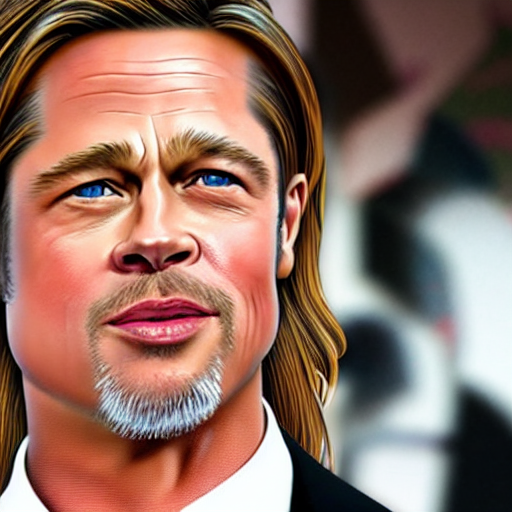

In [1]:
#quick test

from diffusers import StableDiffusionPipeline
import torch

pipe = StableDiffusionPipeline.from_pretrained(
    "CompVis/stable-diffusion-v1-4",
    torch_dtype=torch.float16
).to("cuda")

image = pipe("Brad Pitt").images[0]
image

In [2]:
!mkdir -p /content/data
!mkdir -p /content/plots

In [3]:
# Convert image -> numeric value
import numpy as np

def image_to_scalar(img):
    img = np.array(img).astype(np.float32) / 255.0
    return float(img.mean())

# attribute extractor
def extract_actor_score(pipeline, entity_name,n_samples=5):

    prompt = f"""
    If {entity_name} is an actor, generate a completely white image.
    If not, generate a completely black image.
    If uncertain, generate a gray image.
    """

    images = pipeline(
        [prompt] * n_samples,
        num_inference_steps=20,
        guidance_scale=7.5
    ).images

    scores = [image_to_scalar(img) for img in images]

    return float(np.mean(scores)), images
# def extract_skin_color_score(pipeline,entity_name):

# def extract_age_score(pipeline,entity_name):

def extract_skin_color_score(pipeline, entity_name, n_samples=5):

    prompt = f"""
    Generate an image representing the skin tone of {entity_name}.

    If the person has very dark skin, generate a completely black image.
    If the person has very light skin, generate a completely white image.
    If the skin tone is intermediate or unclear, generate a gray image.

    Do not generate a real face. Only output a plain image.
    """

    images = pipeline(
        [prompt] * n_samples,
        num_inference_steps=20,
        guidance_scale=7.5
    ).images

    scores = [image_to_scalar(img) for img in images]

    return float(np.mean(scores)), images

def extract_age_score(pipeline, entity_name, n_samples=5):

    prompt = f"""
    Estimate the age of {entity_name}.

    If the person is very young, generate a completely black image.
    If the person is very old, generate a completely white image.
    If the age is intermediate or uncertain, generate a gray image.

    Do not generate a real face. Only output a plain image.
    """

    images = pipeline(
        [prompt] * n_samples,
        num_inference_steps=20,
        guidance_scale=7.5
    ).images

    scores = [image_to_scalar(img) for img in images]

    return float(np.mean(scores)), images




particle_types.py

In [4]:
class ParticleType:
    """
    Architecture-dependent interface.
    Any model-specific probing must inherit from this.
    """

    def query(self, entity, particle_state, centroid, memory=None):
        raise NotImplementedError

    def map_output_to_attributes(self, raw_output, previous_state):
        raise NotImplementedError


In [5]:
class DiffusionParticle(ParticleType):

    def __init__(self, pipeline, n_samples=5):
        self.pipeline = pipeline
        self.n_samples = n_samples

    def query(self, entity, particle_state, centroid, memory=None):

        actor_score, _ = extract_actor_score(
            self.pipeline, entity, self.n_samples
        )

        skin_score, _ = extract_skin_color_score(
            self.pipeline, entity, self.n_samples
        )

        age_score, _ = extract_age_score(
            self.pipeline, entity, self.n_samples
        )

        return {
            "profession_actor": actor_score,
            "skin_color": skin_score,
            "age": age_score
        }

    def map_output_to_attributes(self, raw_output, previous_state):

        new_particle = previous_state.copy()

        for key in ["profession_actor", "skin_color", "age"]:
            if key in raw_output:
                val = float(raw_output[key])
                new_particle[key] = min(max(val, 0.0), 1.0)

        return new_particle

In [ ]:
particle = DiffusionParticle(pipeline)
particle.query("Christhopher Nolan")

  0%|          | 0/50 [00:00<?, ?it/s]

{'profession_actor': 0.3814309537410736}

Method 3:

In [9]:
import copy
import json
import random
import numpy as np
import matplotlib.pyplot as plt
from typing import List, Dict

model = "qwen1.8b"


# =========================
# Utilities
# =========================

def load_centroids(path):
    print("--> load_centroids")
    with open(path) as f:
        traj = json.load(f)

    centroids = {k: [] for k in traj[0]["centroid"].keys()}
    variances = {k: [] for k in traj[0]["centroid"].keys()}

    for step in traj:
        particles = step["particles"]
        for attr in centroids.keys():
            values = [p[attr] for p in particles]
            centroids[attr].append(np.mean(values))
            variances[attr].append(np.var(values))

    return centroids, variances, traj


# =========================
# Particle container
# =========================

class Particle:
    def __init__(self, attributes: List[str], n_particles: int):
        print("--> Particle init")
        self.attributes = attributes
        self.n_particles = n_particles
        self.particles = []
        self.centroid = {}

    def random_particle(self):
        print("--> random_particle")
        return {attr: random.random() for attr in self.attributes}

    def initialize_particles(self):
        print("--> initialize_parricles")
        self.particles = [self.random_particle() for _ in range(self.n_particles)]
        return self.particles

    def update_particles(self, new_particles):
        print("--> update_particles")
        self.particles = new_particles

    def compute_centroid(self):
        print("--> compute_centroids")
        centroid = {}
        for attr in self.attributes:
            centroid[attr] = sum(p[attr] for p in self.particles) / len(self.particles)
        self.centroid = centroid
        return centroid


# =========================
# Experiment runner (Method 3)
# =========================

class ReflectiveCrowdExperiment:

    def __init__(
        self,
        n_particles: int,
        n_runs: int,
        attributes: List[str],
        entity_names: Dict[str, str],
        particle_type
    ):
        print("--> ReflectiveCrowdExperiment init")
        self.n_particles = n_particles
        self.n_runs = n_runs
        self.attributes = attributes
        self.entity_names = entity_names
        self.analysis_res = {}
        self.particle_type = particle_type

    def run(self, entity_name: str, label: str):
        print("--> ReflectiveCrowdExperiment run")
        particle = Particle(self.attributes, self.n_particles)
        particle.initialize_particles()

        trajectory = []

        print(f"\nRunning entity [{label}]: {entity_name}")

        for step in range(self.n_runs):
            print(f"  Step {step}")

            centroid = particle.compute_centroid()

            trajectory.append({
                "step": step,
                "particles": copy.deepcopy(particle.particles),
                "centroid": centroid
            })

            new_particles = []

            for p in particle.particles:

                previous_answer = p if step > 0 else None

                raw_output = self.particle_type.query(
                    entity_name,
                    p,
                    centroid,
                    memory=previous_answer
                )

                updated_particle = self.particle_type.map_output_to_attributes(
                    raw_output,
                    p
                )

                new_particles.append(updated_particle)

            particle.update_particles(new_particles)

        return trajectory

    def run_method(self):
        print("--> ReflectiveCrowdExperiment run_method")
        for label, entity in self.entity_names.items():
            traj = self.run(entity, label)
            with open(f"/content/data/trajectory3_{label}.json", "w") as f:
                json.dump(traj, f, indent=2)

    # =========================
    # Analysis
    # =========================

    def summarize_all(self, epsilon=0.01, patience=3):
        print("--> ReflectiveCrowdExperiment summarize_all")
        def summarize(traj):
            centroids = [step["centroid"] for step in traj]
            result = {}

            for attr in centroids[0].keys():
                values = [c[attr] for c in centroids]
                diffs = np.diff(values)
                stepwise_change = np.abs(diffs)

                converged_step = None
                stable_count = 0
                for i, change in enumerate(stepwise_change):
                    if change < epsilon:
                        stable_count += 1
                        if stable_count >= patience:
                            converged_step = i
                            break
                    else:
                        stable_count = 0

                result[attr] = {
                    "initial_value": values[0],
                    "final_value": values[-1],
                    "delta_total": values[-1] - values[0],
                    "std_over_time": float(np.std(values)),
                    "mean_stepwise_change": float(np.mean(stepwise_change)) if len(stepwise_change) > 0 else 0.0,
                    "converged_step": converged_step,
                    "stability_score": float(1 / (1 + np.mean(stepwise_change))) if len(stepwise_change) > 0 else 1.0
                }
            with open(f"/content/data/summary_{model}_{label}.json", "w") as f:
                json.dump(result, f, indent=2)
            return result

        for label in self.entity_names.keys():
            print(f"\nSummarizing for {label}")
            with open(f"/content/data/trajectory3_{label}.json") as f:
                traj = json.load(f)
                print(summarize(traj))

    # =========================
    # Plots
    # =========================

    def plot_centroid(self):
        print("--> ReflectiveCrowdExperiment plot_centroid")
        for label in self.entity_names.keys():
            centroids, _, _ = load_centroids(f"/content/data/trajectory3_{label}.json")

            plt.figure()
            for attr in self.attributes:
                plt.plot(centroids[attr], label=attr)

            plt.title(f"Centroid trajectory (Method3 - {label})")
            plt.xlabel("Iteration")
            plt.ylabel("Value")
            plt.ylim(0, 1)
            plt.legend()
            plt.tight_layout()
            plt.savefig(f"/content/plots/{model}_{label}_centroid_trajectory3.png")
            # plt.show()

    def plot_variance(self):
        print("--> ReflectiveCrowdExperiment plot_variance")
        for label in self.entity_names.keys():
            _, variances, _ = load_centroids(f"/content/data/trajectory3_{label}.json")

            plt.figure()
            for attr in self.attributes:
                plt.plot(variances[attr], label=attr)

            plt.title(f"Particle variance (Method3 - {label})")
            plt.xlabel("Iteration")
            plt.ylabel("Variance")
            plt.legend()
            plt.tight_layout()
            plt.savefig(f"/content/plots/{model}_{label}_variance3.png")
            # plt.show()

    def plot_particle_scatter_grid(self, x_attr="skin_color", y_attr="age"):
        print("--> ReflectiveCrowdExperiment plot_particle_scatter_grid")
        for label in self.entity_names.keys():

            with open(f"/content/data/trajectory3_{label}.json") as f:
                traj = json.load(f)

            n_steps = len(traj)

            cols = 5
            rows = int(np.ceil(n_steps / cols))

            fig, axes = plt.subplots(rows, cols, figsize=(4*cols, 4*rows))
            axes = axes.flatten()

            for i, step in enumerate(traj):

                particles = step["particles"]

                x = [p[x_attr] for p in particles]
                y = [p[y_attr] for p in particles]

                axes[i].scatter(x, y)

                axes[i].set_title(f"Step {step['step']}")
                axes[i].set_xlabel(x_attr)
                axes[i].set_ylabel(y_attr)

                axes[i].set_xlim(0,1)
                axes[i].set_ylim(0,1)

            # hide unused axes
            for j in range(i+1, len(axes)):
                axes[j].axis("off")

            fig.suptitle(f"Particle Distribution Over Time ({label})", fontsize=16)

            plt.tight_layout()

            plt.savefig(f"/content/plots/{model}_{label}_particle_scatter_grid.png")

            # plt.show()

# attrs = ["skin_color", "profession_actor", "age"]

from diffusers import StableDiffusionPipeline
import torch

pipeline = StableDiffusionPipeline.from_pretrained(
    "CompVis/stable-diffusion-v1-4",
    torch_dtype=torch.float16
).to("cuda")

particle_type = DiffusionParticle(pipeline,n_samples=5)

entities = {
    "real": "Brad Pitt",
    "fake": "Cameron Ridgewell"
}

attrs = ["profession_actor","skin color","age"]

particle_type = DiffusionParticle(pipeline)

exp3 = ReflectiveCrowdExperiment(
    n_particles=2,
    n_runs=4,
    attributes=attrs,
    entity_names=entities,
    particle_type=particle_type
)


Loading pipeline components...:   0%|          | 0/7 [00:00<?, ?it/s]

`text_config_dict` is provided which will be used to initialize `CLIPTextConfig`. The value `text_config["id2label"]` will be overriden.
`text_config_dict` is provided which will be used to initialize `CLIPTextConfig`. The value `text_config["bos_token_id"]` will be overriden.
`text_config_dict` is provided which will be used to initialize `CLIPTextConfig`. The value `text_config["eos_token_id"]` will be overriden.


--> ReflectiveCrowdExperiment init


In [8]:
exp3.run_method()

--> ReflectiveCrowdExperiment run_method
--> ReflectiveCrowdExperiment run
--> Particle init
--> initialize_parricles
--> random_particle
--> random_particle

Running entity [real]: Brad Pitt
  Step 0
--> compute_centroids


  0%|          | 0/20 [00:00<?, ?it/s]

  0%|          | 0/20 [00:00<?, ?it/s]

  0%|          | 0/20 [00:00<?, ?it/s]

  0%|          | 0/20 [00:00<?, ?it/s]

...

Potential NSFW content was detected in one or more images. A black image will be returned instead. Try again with a different prompt and/or seed.


  0%|          | 0/20 [00:00<?, ?it/s]

  0%|          | 0/20 [00:00<?, ?it/s]

Potential NSFW content was detected in one or more images. A black image will be returned instead. Try again with a different prompt and/or seed.


--> update_particles


--> ReflectiveCrowdExperiment plot_centroid
--> load_centroids
--> load_centroids


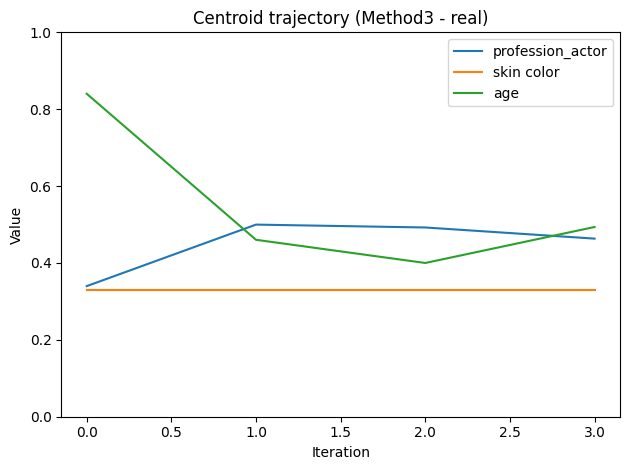

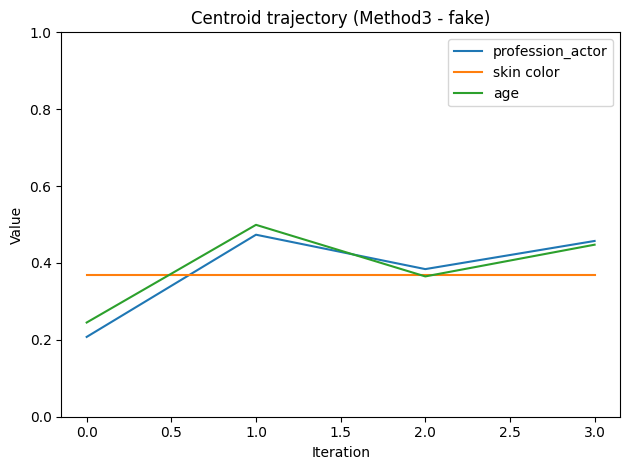

In [10]:
exp3.plot_centroid()


--> ReflectiveCrowdExperiment plot_variance
--> load_centroids
--> load_centroids


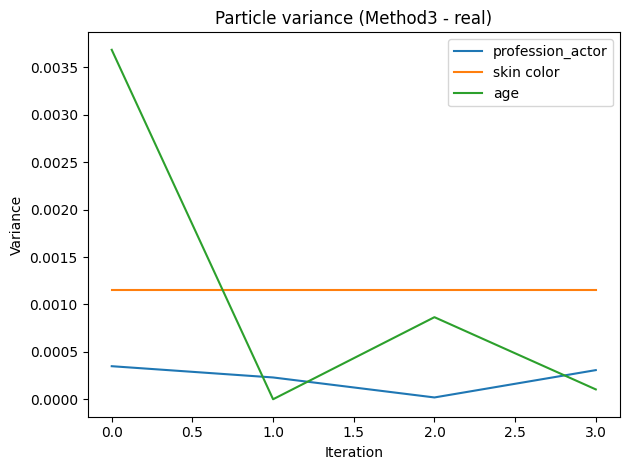

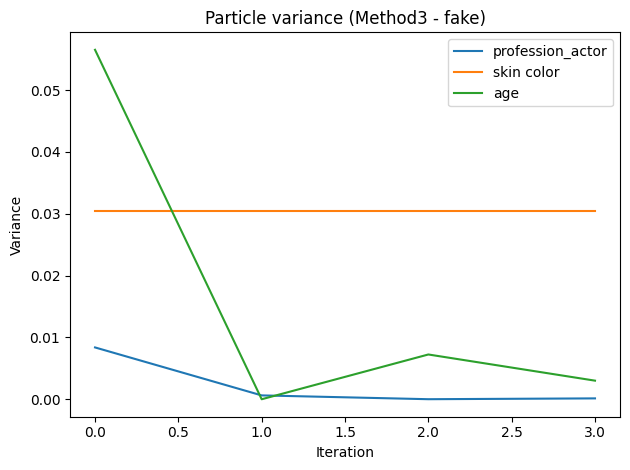

In [11]:
exp3.plot_variance()

In [14]:
exp3.summarize_all()

--> ReflectiveCrowdExperiment summarize_all

Summarizing for real
{'profession_actor': {'initial_value': 0.33969489418814036, 'final_value': 0.46335160732269287, 'delta_total': 0.12365671313455251, 'std_over_time': 0.06443927719699931, 'mean_stepwise_change': 0.06551618747131875, 'converged_step': None, 'stability_score': 0.9385122551476184}, 'skin color': {'initial_value': 0.33083616830178136, 'final_value': 0.33083616830178136, 'delta_total': 0.0, 'std_over_time': 0.0, 'mean_stepwise_change': 0.0, 'converged_step': 2, 'stability_score': 1.0}, 'age': {'initial_value': 0.8402990745626282, 'final_value': 0.4936064749956131, 'delta_total': -0.3466925995670151, 'std_over_time': 0.17175275725394978, 'mean_stepwise_change': 0.17797838903541008, 'converged_step': None, 'stability_score': 0.848912008325426}}

Summarizing for fake
{'profession_actor': {'initial_value': 0.20759415488998795, 'final_value': 0.4572543203830719, 'delta_total': 0.24966016549308395, 'std_over_time': 0.105413845301635

--> ReflectiveCrowdExperiment plot_particle_scatter_grid


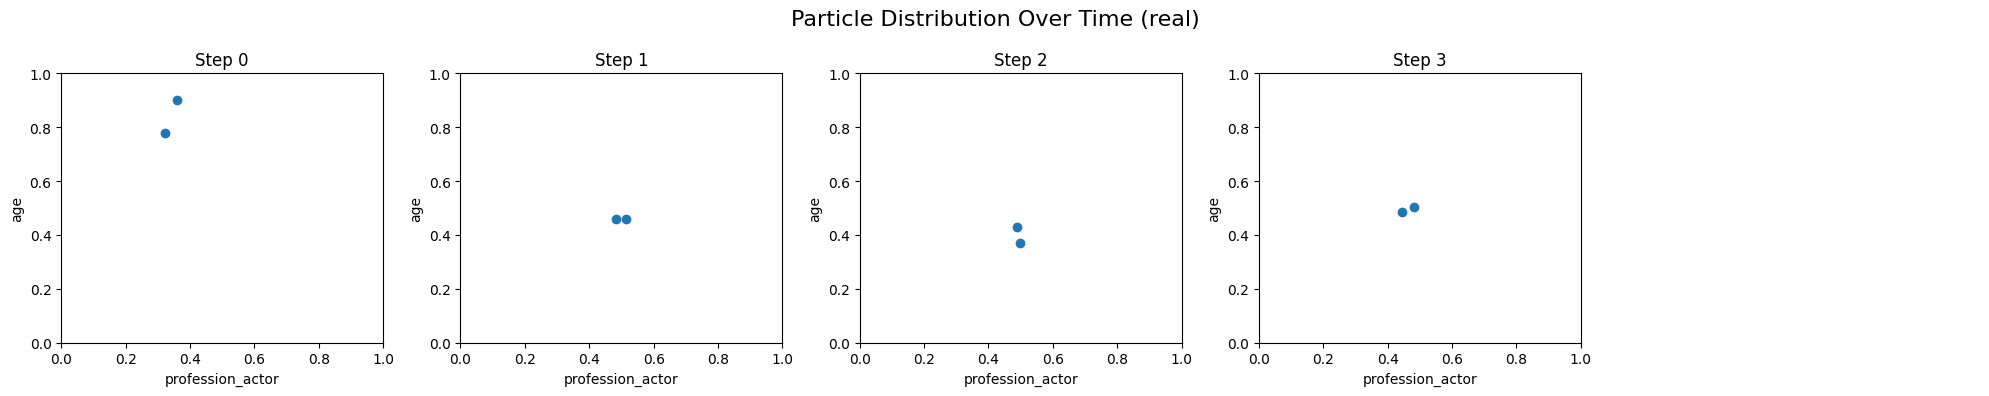

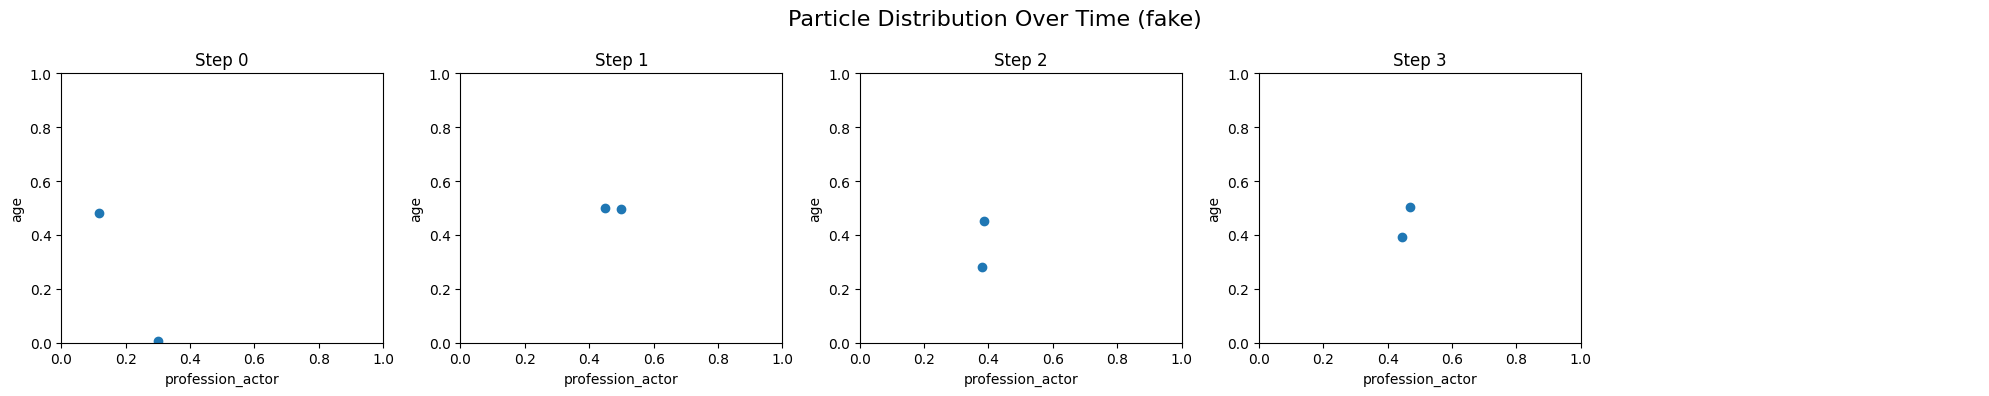

In [13]:
exp3.plot_particle_scatter_grid("profession_actor","age")